In [1]:
import sys; import os; sys.path.append(os.path.abspath('..'))
try:
    import transformers
    import transformers.modeling_utils
    import transformers.utils.import_utils
    transformers.utils.import_utils.check_torch_load_is_safe = lambda *args, **kwargs: None
    transformers.modeling_utils.check_torch_load_is_safe = lambda *args, **kwargs: None
except:
    pass




# Phase 6: First Fine-Tuning Task (Resume Classification)


In [2]:
!pip install transformers datasets evaluate accelerate scikit-learn seaborn matplotlib sentencepiece


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

import transformers
transformers.utils.import_utils.check_torch_load_is_safe = lambda: None
from sklearn.metrics import confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
splits_df = pd.read_csv("resume_metadata_split.csv")
nlp_df = pd.read_csv("nlp_processed_resumes.csv")

df = pd.merge(nlp_df, splits_df[['filename', 'split']], on='filename', how='inner')

labels = sorted(df['category'].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}
num_labels = len(labels)

df['label'] = df['category'].map(label2id)

hg_dataset = DatasetDict({
    'train': Dataset.from_pandas(df[df['split'] == 'train'][['raw_clean_text', 'label']].reset_index(drop=True)),
    'validation': Dataset.from_pandas(df[df['split'] == 'val'][['raw_clean_text', 'label']].reset_index(drop=True)),
    'test': Dataset.from_pandas(df[df['split'] == 'test'][['raw_clean_text', 'label']].reset_index(drop=True))
})
print(hg_dataset)

DatasetDict({
    train: Dataset({
        features: ['raw_clean_text', 'label'],
        num_rows: 1726
    })
    validation: Dataset({
        features: ['raw_clean_text', 'label'],
        num_rows: 369
    })
    test: Dataset({
        features: ['raw_clean_text', 'label'],
        num_rows: 371
    })
})


In [5]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["raw_clean_text"], padding="max_length", truncation=True, max_length=512)

print("Tokenizing datasets...")
tokenized_datasets = hg_dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["raw_clean_text"])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

C:\Users\basse\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\basse\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing datasets...


Map:   0%|          | 0/1726 [00:00<?, ? examples/s]

Map:   0%|          | 0/369 [00:00<?, ? examples/s]

Map:   0%|          | 0/371 [00:00<?, ? examples/s]

In [6]:
metric_f1 = evaluate.load("f1")
metric_acc = evaluate.load("accuracy")
metric_prec = evaluate.load("precision")
metric_rec = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    accuracy = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    precision = metric_prec.compute(predictions=predictions, references=labels, average="macro", zero_division=0)["precision"]
    recall = metric_rec.compute(predictions=predictions, references=labels, average="macro", zero_division=0)["recall"]
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
    
    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir="./deberta-resume-classifier",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=3e-5, warmup_ratio=0.1, max_grad_norm=1.0,
    per_device_train_batch_size=8, # T4 GPU limit for DeBERTa
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=False,
    metric_for_best_model="macro_f1",
    bf16=False, fp16=False, # Enable mixed precision for speed
    logging_dir='./logs',
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [8]:
print("Starting Fine-Tuning Process...")
trainer.train()

Starting Fine-Tuning Process...


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,No log,1.602278,0.742547,0.641733,0.669775,0.618806
2,No log,0.784328,0.837398,0.764765,0.772794,0.759376
3,1.773323,0.682354,0.840108,0.765239,0.778221,0.764751
4,1.773323,0.628541,0.848238,0.769890,0.786037,0.771264
5,0.454333,0.645151,0.845528,0.766877,0.781271,0.766849


TrainOutput(global_step=1080, training_loss=1.0564704064969663, metrics={'train_runtime': 327.3744, 'train_samples_per_second': 26.361, 'train_steps_per_second': 3.299, 'total_flos': 1143642169589760.0, 'train_loss': 1.0564704064969663, 'epoch': 5.0})


--- Final Evaluation on Test Set ---


Test Accuracy: 0.8383
Test Macro F1: 0.7641
Compare this Macro F1 against your Phase 5 Baseline SVM!


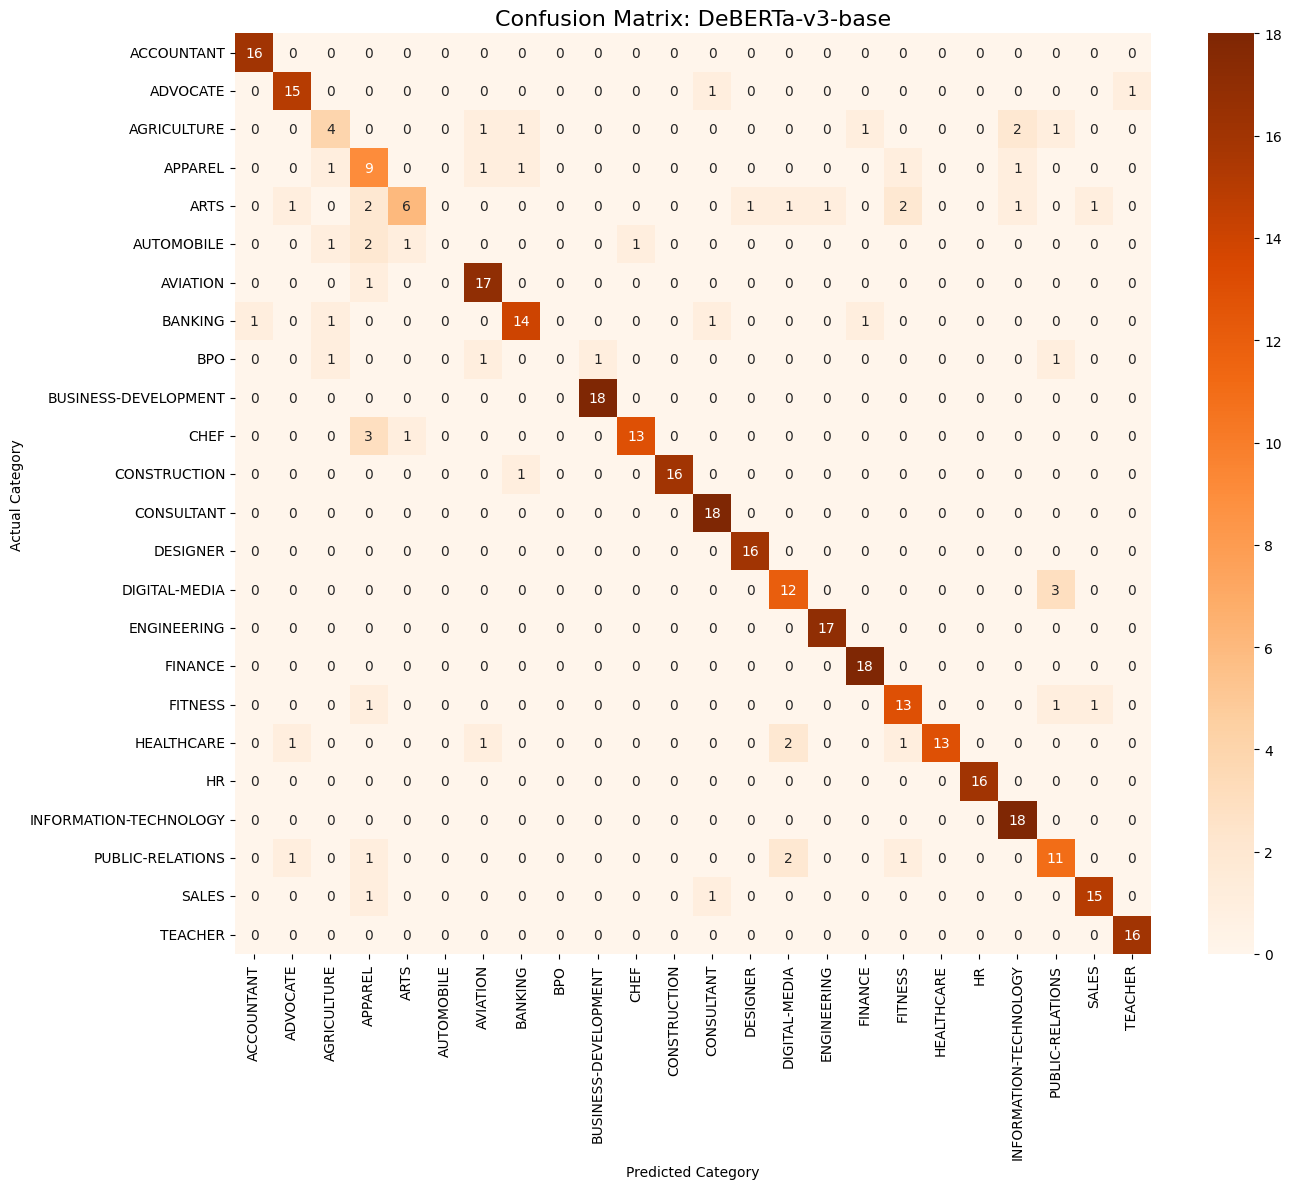


Detailed Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.94      1.00      0.97        16
              ADVOCATE       0.83      0.88      0.86        17
           AGRICULTURE       0.50      0.40      0.44        10
               APPAREL       0.45      0.64      0.53        14
                  ARTS       0.75      0.38      0.50        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       0.81      0.94      0.87        18
               BANKING       0.82      0.78      0.80        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.95      1.00      0.97        18
                  CHEF       0.93      0.76      0.84        17
          CONSTRUCTION       1.00      0.94      0.97        17
            CONSULTANT       0.86      1.00      0.92        18
              DESIGNER       0.94      1.00      0.97        16
      

C:\Users\basse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\basse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\basse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [9]:
print("\n--- Final Evaluation on Test Set ---")
predictions, true_labels, metrics = trainer.predict(tokenized_datasets["test"])

print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
print(f"Test Macro F1: {metrics['test_macro_f1']:.4f}")
print("Compare this Macro F1 against your Phase 5 Baseline SVM!")

pred_labels = np.argmax(predictions, axis=-1)
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix: DeBERTa-v3-base", fontsize=16)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=labels))

In [10]:
model_path = "./final_resume_classifier"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f"Model locally saved to {model_path}")



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model locally saved to ./final_resume_classifier
